# Book Data ETL and Analysis: 
This notebook extracts data from a Kaggle dataset (`books.csv`), loads it into an SQLite database, and analyzes book statistics such as average ratings, authors, and publication trends.

In [11]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load CSV into SQLite Database
The function below reads the CSV, cleans column names, and populates three tables:
- `books`
- `book_stats`
- `book_authors`

In [12]:
def load_csv_to_db(db_path="books.db", csv_path="books.csv"):
    df = pd.read_csv(csv_path, on_bad_lines='skip')
    df.columns = df.columns.str.strip()
    conn = sqlite3.connect(db_path)
    cur = conn.cursor()


    for _,row in df.iterrows():
        book_id = row.get('bookID')
        title = row['title']
        pub_year = row.get('publication_date', None)#.get because the table has to have a value but the dataset might not have one
        isbn = row.get('isbn', None)
        lang = row.get('language_code', None)
        pages = row.get('num_pages', None)

        cur.execute("""
            INSERT OR IGNORE INTO books(bookID, title, publication_date, isbn,
            language_code, num_pages)
            VALUES (?, ?, ?, ?, ?, ?)""",
            (book_id, title, pub_year, isbn, lang, pages))
        avg = row.get('average_rating', None)
        count = row.get('ratings_count', None)
        tr_count = row.get('text_reviews_count', None)
        cur.execute("""
            INSERT OR IGNORE INTO book_stats(bookID, average_rating, ratings_count, text_reviews_count)
            VALUES (?, ?, ?, ?)""",
            (book_id, avg, count, tr_count))

        authors = row.get('authors', "")
        author_list = [a.strip() for a in authors.split(";")]
        for a in author_list:
            cur.execute("INSERT OR IGNORE INTO authors (name) VALUES (?)", (a,))
            cur.execute("SELECT author_id FROM authors WHERE name = ?", (a,))
            a_id = cur.fetchone()[0]
            cur.execute("""INSERT OR IGNORE INTO book_authors (bookID, author_id) VALUES (?, ?)""", (book_id, a_id))
    conn.commit()
    conn.close()

In [13]:
load_csv_to_db()
print(" Data successfully loaded into SQLite database.")

 Data successfully loaded into SQLite database.


In [14]:
conn = sqlite3.connect("books.db")

# Preview the books table
books_df = pd.read_sql_query("SELECT * FROM books LIMIT 10;", conn)
books_df.head()

,bookID,title,publication_date,isbn,language_code,num_pages
0,1,Harry Potter and the Half-Blood Prince (Harry ...,9/16/2006,0439785960,eng,652
1,2,Harry Potter and the Order of the Phoenix (Har...,9/1/2004,0439358078,eng,870
2,4,Harry Potter and the Chamber of Secrets (Harry...,11/1/2003,0439554896,eng,352
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,5/1/2004,043965548X,eng,435
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,9/13/2004,0439682584,eng,2690


### Top 10 most rated books

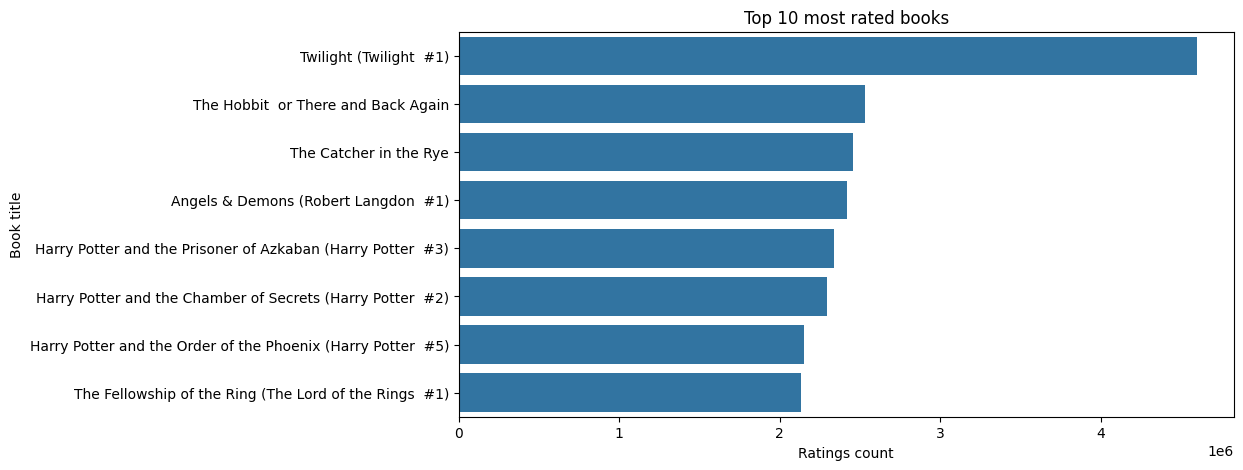

In [15]:
ratings_df = pd.read_sql_query("""
    SELECT b.title, s.ratings_count
    FROM books b
    JOIN book_stats s ON b.bookID = s.bookID
    ORDER BY s.ratings_count DESC
    LIMIT 15""", conn)

plt.figure(figsize=(10,5))
sns.barplot(data = ratings_df, x = 'ratings_count', y = 'title')
plt.title('Top 10 most rated books')
plt.xlabel('Ratings count')
plt.ylabel('Book title')
plt.show()

### Distribution of average ratings

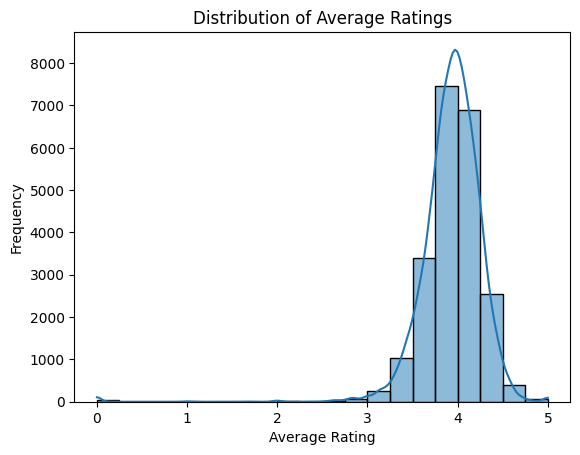

In [16]:
avg_df = pd.read_sql_query("SELECT average_rating FROM book_stats;", conn)
sns.histplot(avg_df['average_rating'], bins = 20, kde = True)
plt.title('Distribution of Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.show()

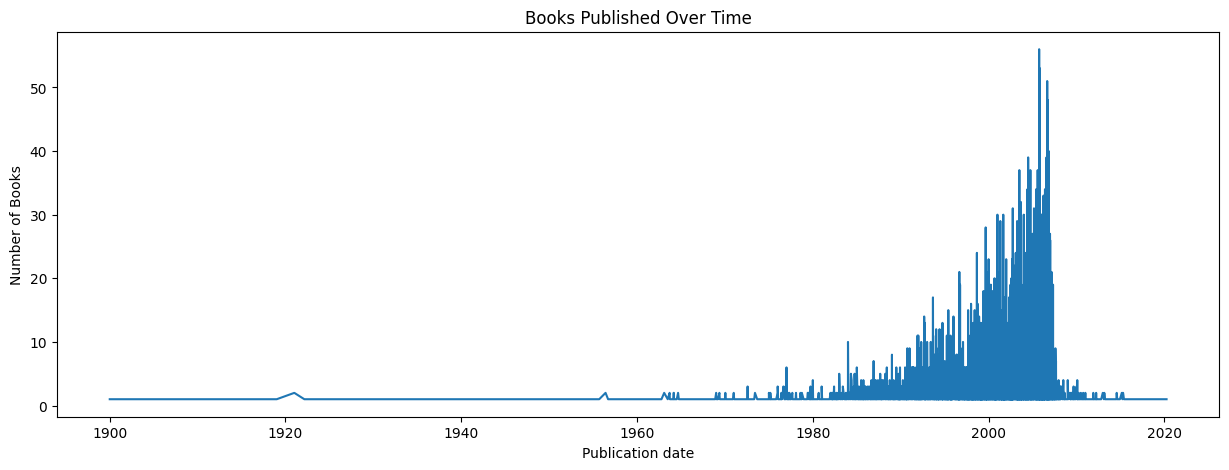

In [23]:
pub_df = pd.read_sql_query("""
    SELECT publication_date, COUNT(*) as num_books
    FROM books
    WHERE publication_date IS NOT NULL
    GROUP BY publication_date
    ORDER BY publication_date
""", conn)

pub_df['publication_date'] = pd.to_datetime(pub_df['publication_date'], errors='coerce')
pub_df = pub_df.dropna(subset=['publication_date'])

pub_df['year'] = pub_df['publication_date'].dt.year
yearly = pub_df.groupby('year')['num_books'].sum().reset_index()

plt.figure(figsize = (15,5))
sns.lineplot(data = pub_df, x = 'publication_date', y = 'num_books')
plt.title('Books Published Over Time')
plt.xlabel('Publication date')
plt.ylabel('Number of Books')
plt.show()

### Key Insights
- Average ratings are generally high, with most books between 3.5–4.5.
- There’s an increasing trend in books published over time but with particularly large growth since 1980, up until the 2010s where there is a sharp drop